In [3]:
print('Hello, World!')

Hello, World!


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import glob
import numpy as np
from mpl_toolkits.mplot3d import Axes3D as ax

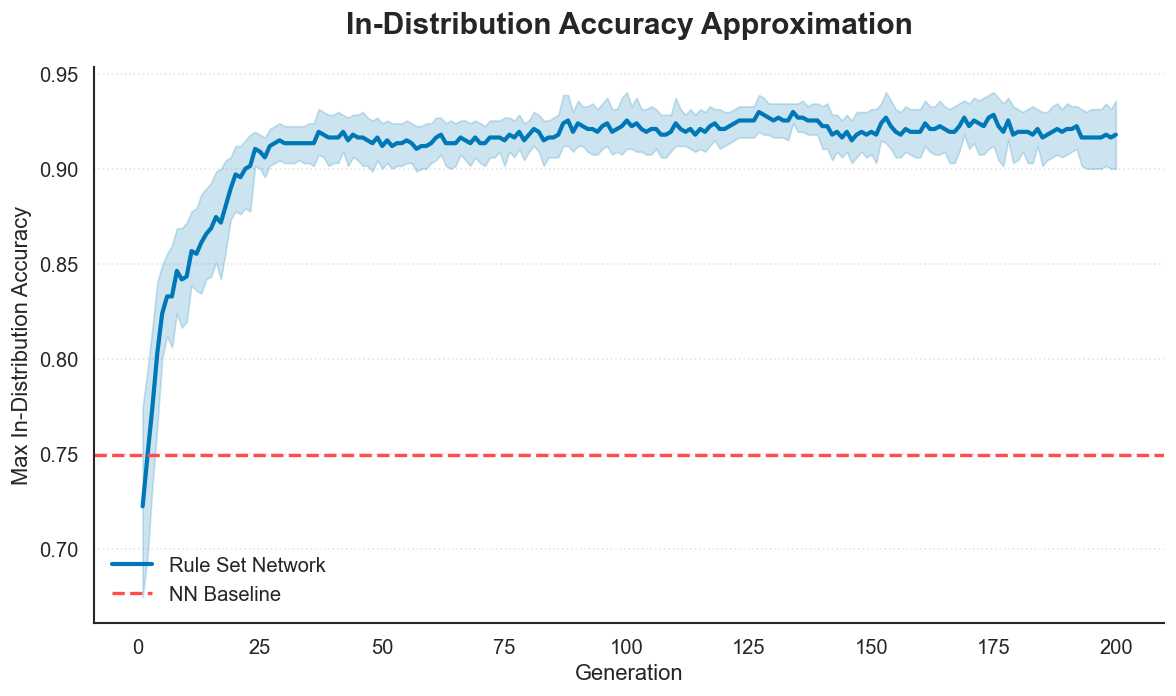

In [3]:
# Figure 4.2
# Demonstrating approximation of in-distribution accuracy of rule sets over 200 generations


# Configuration
experiment_dir = "../../../neurorule-data/multi-objective/bc/ID/0.95/"
file_pattern = os.path.join(experiment_dir, "**/experiment_stats.csv")



all_data = []

# 1. Iterate through directories and collect CSVs
# recursive=True ensures we find files in all subdirectories
for file_path in glob.glob(file_pattern, recursive=True):
    df = pd.read_csv(file_path)
    
    # Ensure we only take what's needed to save memory
    if 'generation' in df.columns and 'max_in_distribution_accuracy' in df.columns:
        all_data.append(df[['generation', 'max_in_distribution_accuracy']])

# 2. Combine all dataframes into one long-form dataframe
combined_df = pd.concat(all_data, ignore_index=True)

# 3. Create the plot
# Final Aesthetic Setup
plt.figure(figsize=(10, 6), dpi=120)
sns.set_context("notebook", font_scale=1.1)
sns.set_style("white")

# sns.lineplot automatically calculates the mean and 95% CI (shading)
sns.lineplot(
    data=combined_df, 
    x='generation', 
    y='max_in_distribution_accuracy',
    color='#0077b6',  # Deep, modern blue
    label="Rule Set Network",
    linewidth=2.5
)

# plt.ylim(0.5, 1)

plt.axhline(
    y=0.7494, 
    color='#ff4d4d', # Vibrant but professional red
    linewidth=2, 
    linestyle='--', 
    label='NN Baseline'
)

sns.despine() # Makes it look "cool" and open
plt.grid(axis='y', linestyle=':', alpha=0.5) # Subtle horizontal guides
plt.legend(frameon=False) # Removes the box around the legend

plt.title('In-Distribution Accuracy Approximation', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Generation')
plt.ylabel('Max In-Distribution Accuracy')
plt.tight_layout()
plt.show()

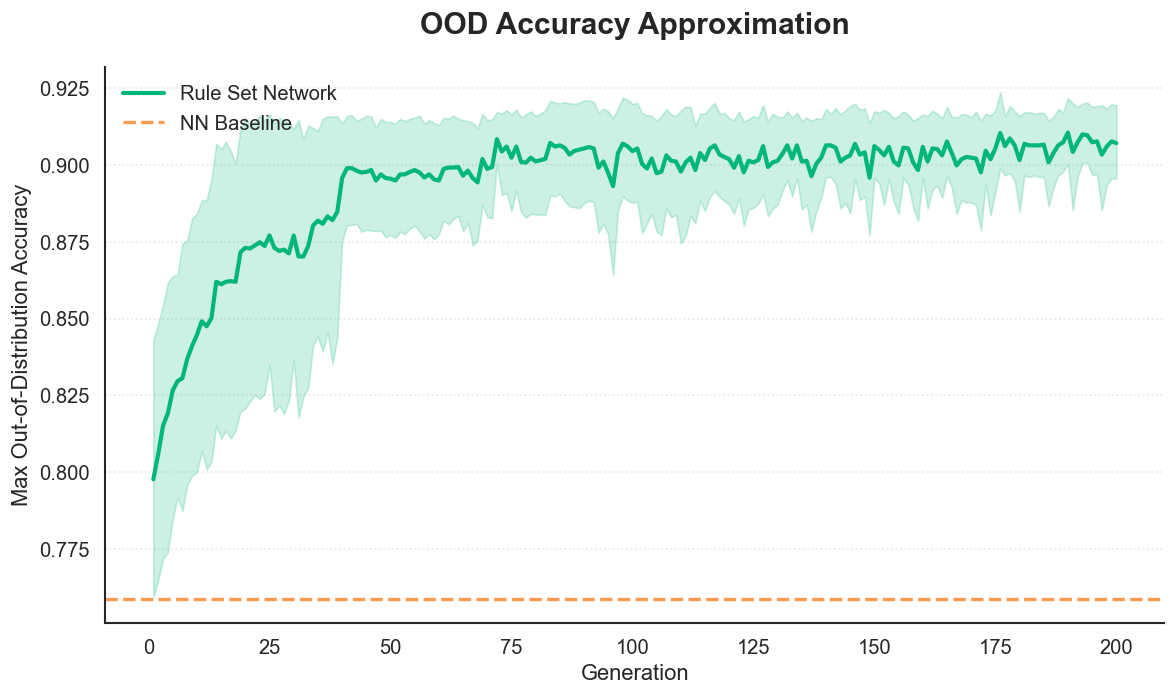

In [19]:
# Figure 4.3
# Demonstrating approximation of out-of-distribution accuracy of rule sets over 200 generations


# Configuration
experiment_dir = "../../../neurorule-data/single-objective/bc/ID/0.80/"
file_pattern = os.path.join(experiment_dir, "**/experiment_stats.csv")



all_data = []

# 1. Iterate through directories and collect CSVs
# recursive=True ensures we find files in all subdirectories
for file_path in glob.glob(file_pattern, recursive=True):
    df = pd.read_csv(file_path)
    
    # Ensure we only take what's needed to save memory
    if 'generation' in df.columns and 'max_out_of_distribution_accuracy' in df.columns:
        all_data.append(df[['generation', 'max_out_of_distribution_accuracy']])

# 2. Combine all dataframes into one long-form dataframe
combined_df = pd.concat(all_data, ignore_index=True)

# 3. Create the plot
# Final Aesthetic Setup
plt.figure(figsize=(10, 6), dpi=120)
sns.set_context("notebook", font_scale=1.1)
sns.set_style("white")

# sns.lineplot automatically calculates the mean and 95% CI (shading)
sns.lineplot(
    data=combined_df, 
    x='generation', 
    y='max_out_of_distribution_accuracy',
    color="#00b679",  # Deep, modern blue
    label="Rule Set Network",
    linewidth=2.5
)

plt.axhline(
    y=0.7586, 
    color="#ff9a4d", # Vibrant but professional red
    linewidth=2, 
    linestyle='--', 
    label='NN Baseline'
)

sns.despine() # Makes it look "cool" and open
plt.grid(axis='y', linestyle=':', alpha=0.5) # Subtle horizontal guides
plt.legend(frameon=False) # Removes the box around the legend

plt.title('OOD Accuracy Approximation', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Generation')
plt.ylabel('Max Out-of-Distribution Accuracy')
plt.tight_layout()
# plt.legend()
plt.show()

In [5]:
# Figure 4.5
# Demonstrating multi-objective approximation of out-of-distribution accuracy of rule sets over 200 generations

def plot_multi_vs_single_objective(dataset, data_range, metric, baseline):
    # dataset = "diabetes"
    # data_range = "0.95"
    # metric = "max_out_of_distribution_accuracy"
    # baseline = 0.717

    # Configuration


    experiment_dir = "../../../neurorule-data-9/baseline/" + "/ID/" + data_range + "/uci_heart_test/"
    # experiment_dir = "../../../neurorule-syn-0.95/0.95/"
    file_pattern = os.path.join(experiment_dir, "**/experiment_stats.csv")

    all_data = []

    # 1. Iterate through directories and collect CSVs
    # recursive=True ensures we find files in all subdirectories
    for file_path in glob.glob(file_pattern, recursive=True):
        df = pd.read_csv(file_path)
        
        # Ensure we only take what's needed to save memory
        if 'generation' in df.columns and metric in df.columns:
            all_data.append(df[['generation', metric]])

    # 2. Combine all dataframes into one long-form dataframe
    combined_df = pd.concat(all_data, ignore_index=True)





    experiment_dir2 = "../../../neurorule-syn-heart/candidate-solutions/heart/" + data_range + "/uci_heart_test/"
    file_pattern2 = os.path.join(experiment_dir2, "**/experiment_stats.csv")

    all_data2 = []

    for file_path in glob.glob(file_pattern2, recursive=True):
        df = pd.read_csv(file_path)
        
        # Ensure we only take what's needed to save memory
        if 'generation' in df.columns and metric in df.columns:
            all_data2.append(df[['generation', metric]])

    combined_df2 = pd.concat(all_data2, ignore_index=True)




    # experiment_dir3 = "../../../neurorule-data/baseline/" + dataset + "/ID/" + data_range + "/"
    # file_pattern3 = os.path.join(experiment_dir3, "**/experiment_stats.csv")

    # all_data3 = []

    # for file_path in glob.glob(file_pattern3, recursive=True):
    #     df = pd.read_csv(file_path)
        
    #     # Ensure we only take what's needed to save memory
    #     if 'generation' in df.columns and metric in df.columns:
    #         all_data3.append(df[['generation', metric]])

    # combined_df3 = pd.concat(all_data3, ignore_index=True)






    # 3. Create the plot
    # Final Aesthetic Setup
    plt.figure(figsize=(10, 6), dpi=120)
    sns.set_context("notebook", font_scale=1.1)
    sns.set_style("white")

    # sns.lineplot automatically calculates the mean and 95% CI (shading)
    

    # sns.lineplot(
    #     data=combined_df3, 
    #     x='generation', 
    #     y=metric,
    #     color="#7000b6",  # Deep, modern blue
    #     # color="#3d00b6",  # Deep, modern blue
    #     # label="Rule Set Network Ground Truth Training",
    #     label="Rule Set Baseline Fitness",
    #     linewidth=2.5
    # )


    sns.lineplot(
        data=combined_df, 
        x='generation', 
        y=metric,
        color='#0077b6',  # Deep, modern blue
        # color="#00b679",  # Deep, modern blue
        # label="Rule Set Network Synthetic Data Training",
        # label="Rule Set Network Multi-Objective Fitness",
        label="Ground Truth Accuracy Evolved Rule Set",
        linewidth=2.5
    )

    sns.lineplot(
        data=combined_df2, 
        x='generation', 
        y=metric,
        # color='#0077b6',  # Deep, modern blue
        color="#00b679",  # Deep, modern blue
        # color="#3d00b6",  # Deep, modern blue
        # label="Rule Set Network Ground Truth Training",
        label="Synthetic Data Surrogate Evolved Rule Set",
        linewidth=2.5
    )

    

    

    plt.axhline(
        y=baseline, 
        color="#ff4d4d", # Vibrant but professional red
        linewidth=2, 
        linestyle='--', 
        label='NN Baseline'
    )

    sns.despine() # Makes it look "cool" and open
    plt.grid(axis='y', linestyle=':', alpha=0.5) # Subtle horizontal guides
    plt.legend(frameon=False) # Removes the box around the legend

    # plt.ylim(0.80, 0.92)

    # plt.title('ID Accuracy Approximation', fontsize=18, fontweight='bold', pad=20)
    plt.xlabel('Generation')
    plt.ylabel('Max Accuracy')
    plt.tight_layout()
    # plt.legend()
    plt.show()

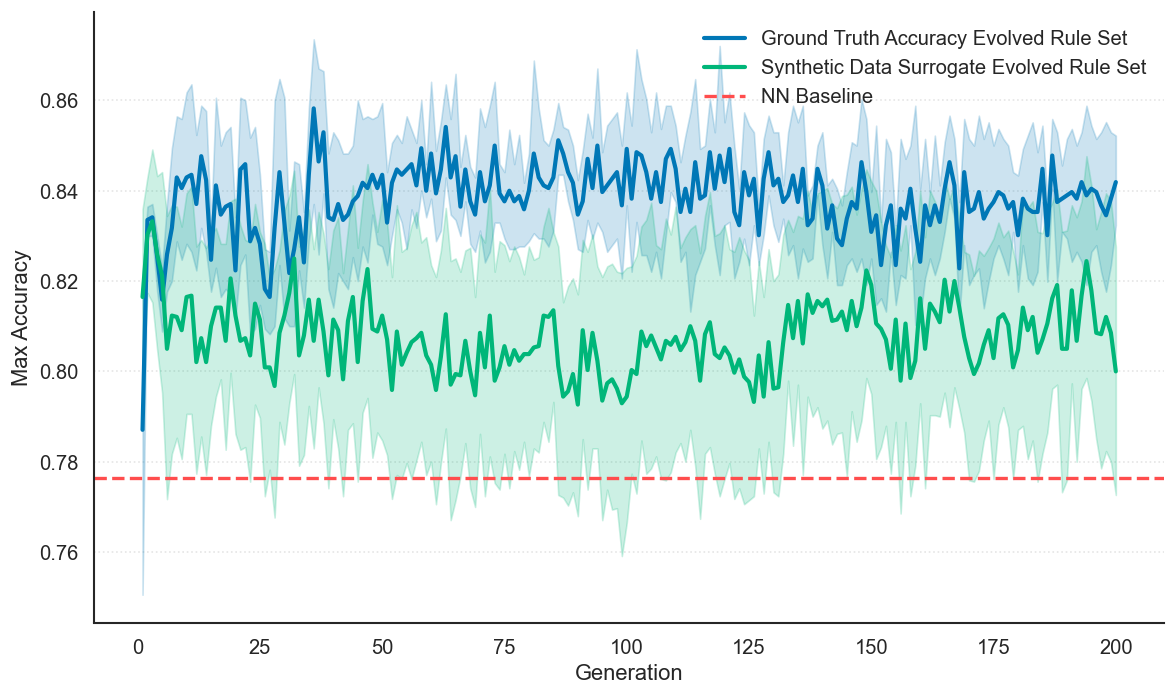

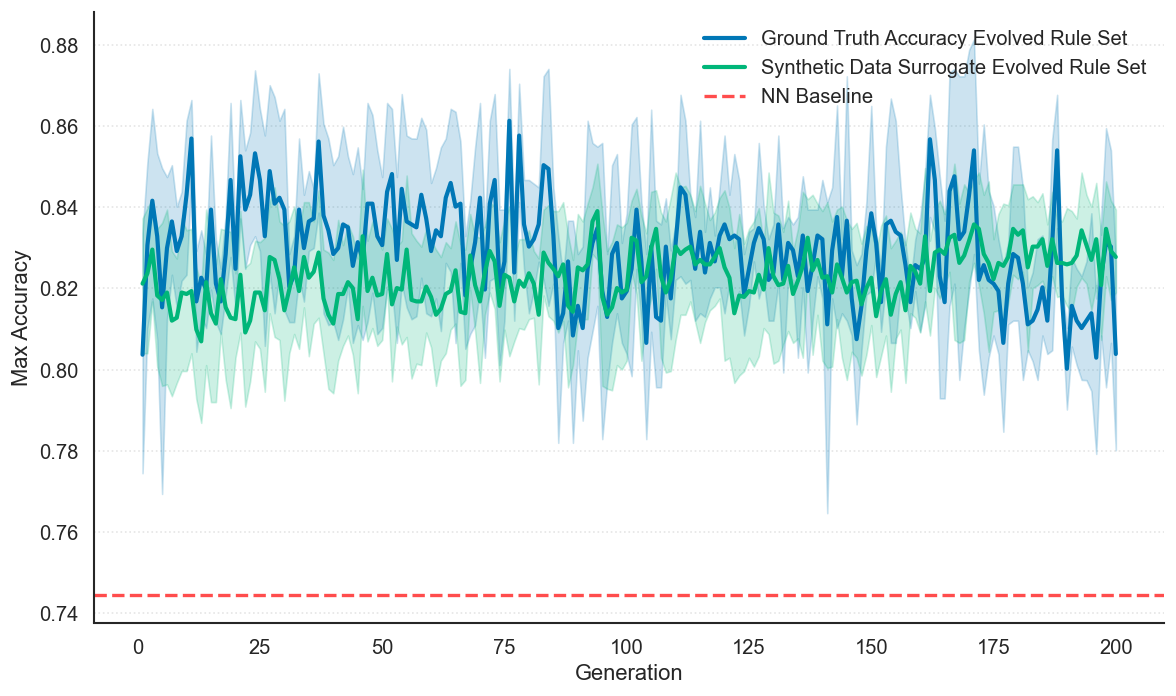

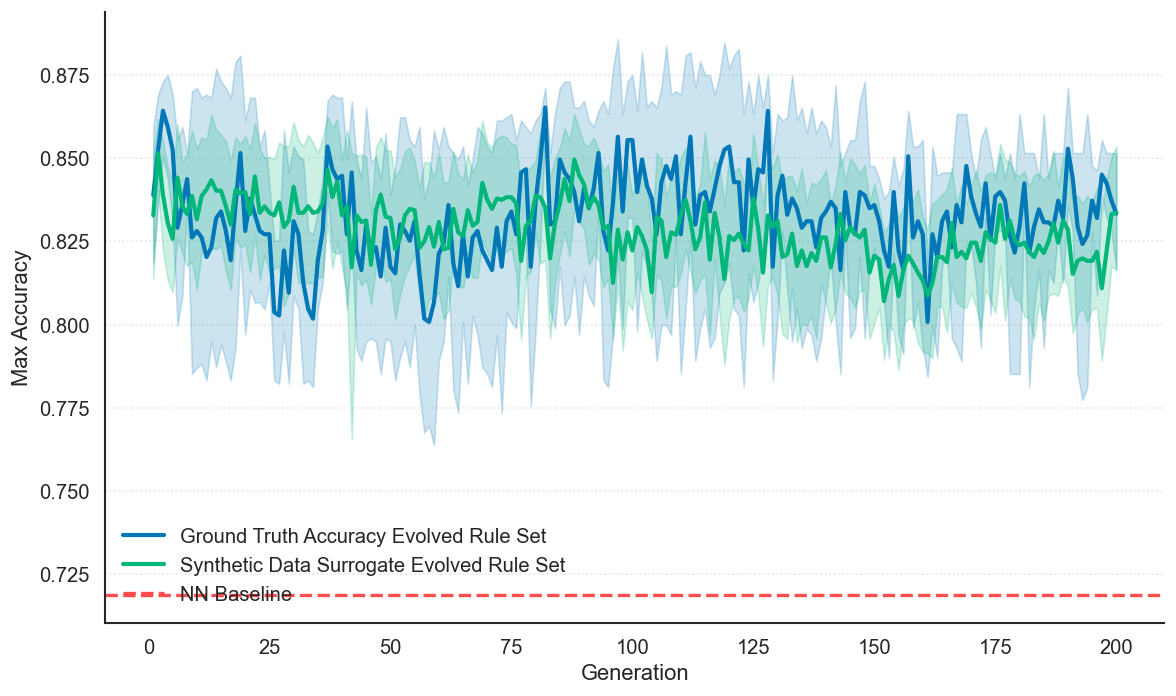

In [6]:
bc_ranges = {
    "title": "bc",
    "ranges": {
        "0.80": {
            "id": 1.0,
            "ood": 0.7586,
            "baseline": 0.7696,
        },
        "0.90": {
            "id": 0.9787,
            "ood": 0.8846,
            "baseline": 0.8961,
        },
        "0.95": {
            "id": 0.9254,
            "ood": 0.9872,
            "baseline": 0.9735,
        },
    },
}

heart_ranges = {
    "title": "heart",
    "ranges": {
        "0.80": {
            "id": 0.8879,
            "ood": 0.7765,
            "baseline": 0.8048,
        },
        "0.90": {
            "id": 0.8605,
            "ood": 0.7445,
            "baseline": 0.7816
        },
        "0.95": {
            "id": 0.9023,
            "ood": 0.7188,
            "baseline": 0.7815
        },
    },
}

diabetes_ranges = {
    "title": "diabetes",
    "ranges": {
        "0.80": {
            "id": 0.7494,
            "ood": 0.6916,
            "baseline": 0.6919,
        },
        "0.90": {
            "id": 0.7262,
            "ood": 0.6967,
            "baseline": 0.6970,
        },
        "0.95": {
            "id": 0.7259,
            "ood": 0.717,
            "baseline": 0.7171
        },
    },
}

dataset = heart_ranges

for r in dataset["ranges"]:
    plot_multi_vs_single_objective(
        dataset=dataset["title"],
        data_range=r,
        metric="max_out_of_distribution_accuracy",
        baseline=dataset["ranges"][r]["ood"]
    )